In [25]:
import pandas as pd
# import matplotlib
# matplotlib.use("agg")
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np


In [26]:
from xgboost import XGBClassifier, plot_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report,roc_auc_score, roc_curve, precision_recall_curve,
                              confusion_matrix, ConfusionMatrixDisplay, recall_score,precision_score)
from xgboost import plot_importance
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

**Load data**

In [27]:
df=pd.read_csv('uttarakhand_grid_features(for_baseline_model).csv')

In [28]:
df.head()

,longitude,latitude,NDVI,NDMI,temperature_2m,temperature_2m_max,dewpoint_temperature_2m,total_precipitation_sum,u_component_of_wind_10m,v_component_of_wind_10m,surface_pressure,volumetric_soil_water_layer_1,elevation,slope,aspect,fire_occurred
0,79.056237,31.454510,0.034391,0.188550,266.61887,272.42578,259.66250,0.001255,1.068875,0.566842,57139.035,0.111080,5012.1400,14.844332,199.069610,0
1,79.047253,31.445527,0.016374,0.381851,264.61670,270.03296,259.06317,0.001604,0.879129,0.616004,55585.973,0.186933,5200.7480,18.319778,190.935290,0
2,79.056237,31.445527,0.011619,0.468679,264.82630,270.37836,258.34160,0.001414,0.959130,0.724336,55237.586,0.155784,5150.1350,17.898663,154.888230,0
3,79.065220,31.445527,0.023675,0.383258,264.82630,270.37836,258.34160,0.001414,0.959130,0.724336,55237.586,0.155784,5194.6226,17.689997,198.592040,0
4,79.074203,31.445527,0.024967,0.321524,264.82630,270.37836,258.34160,0.001414,0.959130,0.724336,55237.586,0.155784,5139.0874,19.879358,125.371086,0


In [29]:
feature_cols=["NDVI", "NDMI", "temperature_2m", "temperature_2m_max", "dewpoint_temperature_2m",
    "total_precipitation_sum", "u_component_of_wind_10m", "v_component_of_wind_10m",
    "surface_pressure", "volumetric_soil_water_layer_1",
    "elevation", "slope", "aspect"]


In [30]:
X=df[feature_cols]
y=df["fire_occurred"]


In [31]:
X_train,X_test,y_train,y_test= train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

In [32]:
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()

weight = neg_count / pos_count

print(f"neg={neg_count}, pos={pos_count}, scale_pos_weight={weight:.3f}")

neg=23716, pos=24631, scale_pos_weight=0.963


**Hyperparameter search space**

In [33]:
param_dist = {
    "n_estimators": [150, 250, 400],
    "max_depth": [4, 6, 8, 10],
    "learning_rate": [0.03, 0.05, 0.08, 0.1],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
}

**Base(untrained) model template used by RandomizedSearchCV**

In [ ]:
base_model = XGBClassifier(
    scale_pos_weight=weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=1, #avoid nested-parallelism conflict with RandomizedSearchCV
)

In [35]:
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [ ]:
import time
t0 = time.time()
search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=20,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,  #search gets all parallelism
    verbose=1,
    random_state=42,
)
search.fit(X_train, y_train)
print(f"Done in {time.time()-t0:.1f}s")
print("Best params:", search.best_params_)
print("Best CV ROC-AUC:", search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Done in 70.8s
Best params: {'subsample': 0.7, 'n_estimators': 250, 'max_depth': 10, 'learning_rate': 0.03, 'colsample_bytree': 0.7}
Best CV ROC-AUC: 0.9298809570775587


In [37]:
base_model = search.best_estimator_
y_pred = base_model.predict(X_test)
y_proba = base_model.predict_proba(X_test)[:, 1]

In [38]:
report = classification_report(y_test, y_pred, digits=3)
auc = roc_auc_score(y_test, y_proba)
cm = confusion_matrix(y_test, y_pred)
print(report)
print("Test ROC-AUC:", auc)
print(cm)

              precision    recall  f1-score   support

           0      0.876     0.806     0.840      5929
           1      0.827     0.890     0.857      6158

    accuracy                          0.849     12087
   macro avg      0.852     0.848     0.849     12087
weighted avg      0.851     0.849     0.849     12087

Test ROC-AUC: 0.9304687311271503
[[4781 1148]
 [ 675 5483]]


**Overfitting check (train vs test ROC-AUC)**

In [39]:
train_proba=base_model.predict_proba(X_train)[:,1]
train_auc=roc_auc_score(y_train,train_proba)
print(f"\nTrain ROC-AUC: {train_auc:.4f}| Test ROC-AUC:(auc:.4f)|Gap:{train_auc-auc:.4f}")


Train ROC-AUC: 0.9712| Test ROC-AUC:(auc:.4f)|Gap:0.0408


**a gap under -0.03-0.05 is healthy. A larger gap suggests overfitting**

In [ ]:
base_model.save_model("xgb_fire_model_tuned.json")

# save result as a plain text file
with open("tuning_results.txt", "w") as f:
    f.write(f"Best params: {search.best_params_}\n")
    f.write(f"Best CV ROC-AUC: {search.best_score_}\n\n")
    f.write("Test set performance:\n")
    f.write(report)
    f.write(f"\nROC-AUC: {auc}\n")
    f.write(f"Confusion matrix:\n{cm}\n")
print("SAVED")


SAVED


**Thresholad tuning (find the best threshold for recall)**

In [41]:
print("\n--- Threshold tuning ---")
thresholds = np.arange(0.1, 0.9, 0.05)
threshold_results = []
for t in thresholds:
    pred = (y_proba >= t).astype(int)
    r = recall_score(y_test, pred)
    p = precision_score(y_test, pred)
    threshold_results.append((t, r, p))
    print(f"Threshold={t:.2f} | Recall={r:.3f} | Precision={p:.3f}")

threshold_df = pd.DataFrame(threshold_results, columns=["threshold", "recall", "precision"])
threshold_df.to_csv("threshold_tuning_results.csv", index=False)
# Pick a threshold from this table where recall is high enough for your use case
# (e.g. recall >= 0.90) without precision dropping too much.


--- Threshold tuning ---
Threshold=0.10 | Recall=0.989 | Precision=0.697
Threshold=0.15 | Recall=0.985 | Precision=0.714
Threshold=0.20 | Recall=0.977 | Precision=0.732
Threshold=0.25 | Recall=0.968 | Precision=0.751
Threshold=0.30 | Recall=0.956 | Precision=0.766
Threshold=0.35 | Recall=0.943 | Precision=0.781
Threshold=0.40 | Recall=0.930 | Precision=0.798
Threshold=0.45 | Recall=0.909 | Precision=0.814
Threshold=0.50 | Recall=0.890 | Precision=0.827
Threshold=0.55 | Recall=0.869 | Precision=0.844
Threshold=0.60 | Recall=0.843 | Precision=0.857
Threshold=0.65 | Recall=0.808 | Precision=0.873
Threshold=0.70 | Recall=0.768 | Precision=0.891
Threshold=0.75 | Recall=0.710 | Precision=0.907
Threshold=0.80 | Recall=0.645 | Precision=0.923
Threshold=0.85 | Recall=0.559 | Precision=0.939


In [42]:
import seaborn as sns

**Confusion Matrix plot**

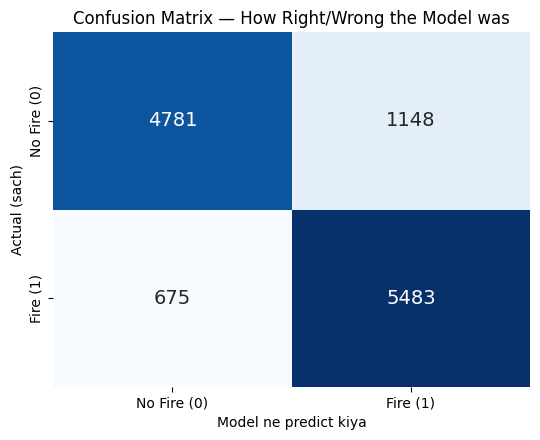

In [49]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5.5, 4.5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Fire (0)", "Fire (1)"],
    yticklabels=["No Fire (0)", "Fire (1)"],
    cbar=False,
    annot_kws={"size": 14}
)

plt.xlabel("Model ne predict kiya")
plt.ylabel("Actual (sach)")
plt.title("Confusion Matrix — How Right/Wrong the Model was")

plt.tight_layout()
plt.show()

**ROC curve**

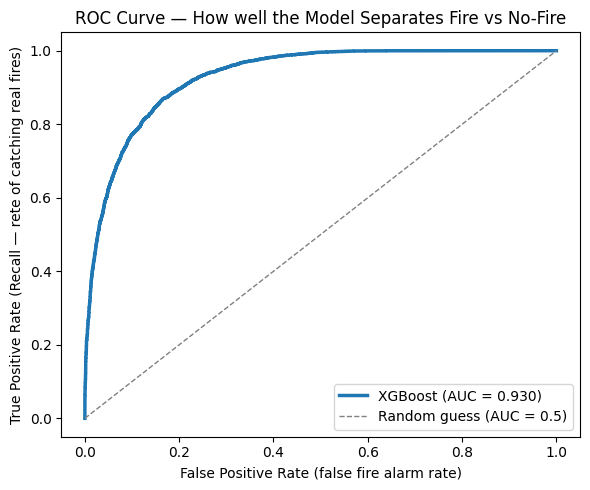

In [50]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="#1f77b4", lw=2.5, label=f"XGBoost (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Random guess (AUC = 0.5)")
plt.xlabel("False Positive Rate (false fire alarm rate)")
plt.ylabel("True Positive Rate (Recall — rete of catching real fires)")
plt.title("ROC Curve — How well the Model Separates Fire vs No-Fire")
plt.legend(loc="lower right")
plt.tight_layout()

**Presion-Recall Curve**

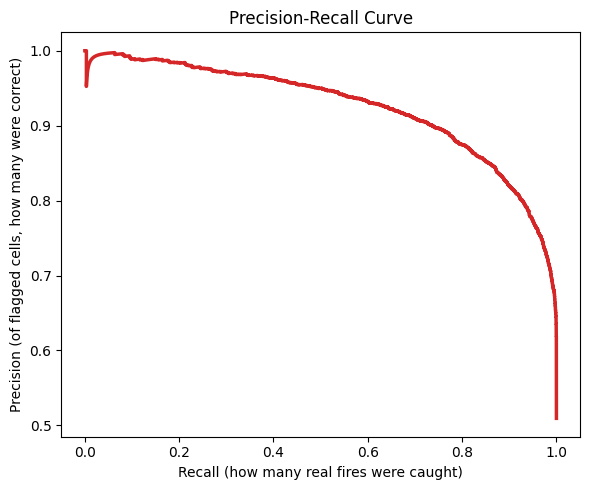

In [51]:
prec, rec, _ = precision_recall_curve(y_test, y_proba)
plt.figure(figsize=(6, 5))
plt.plot(rec, prec, color="#d62728", lw=2.5)
plt.xlabel("Recall (how many real fires were caught)")
plt.ylabel("Precision (of flagged cells, how many were correct)")
plt.title("Precision-Recall Curve")
plt.tight_layout()
plt.show()

**Feature Importance**

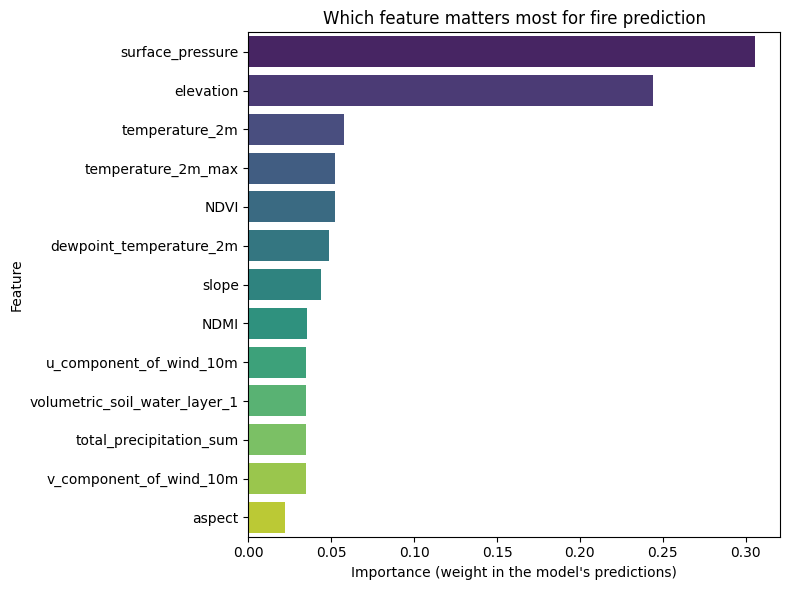

In [52]:
importance = base_model.feature_importances_
imp_df = pd.DataFrame({"feature": feature_cols, "importance": importance})
imp_df = imp_df.sort_values("importance", ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=imp_df, y="feature", x="importance", hue="feature",
            palette="viridis", legend=False)
plt.xlabel("Importance (weight in the model's predictions)")
plt.ylabel("Feature")
plt.title("Which feature matters most for fire prediction")
plt.tight_layout()
plt.show()

**Feature distribution (top 4)**

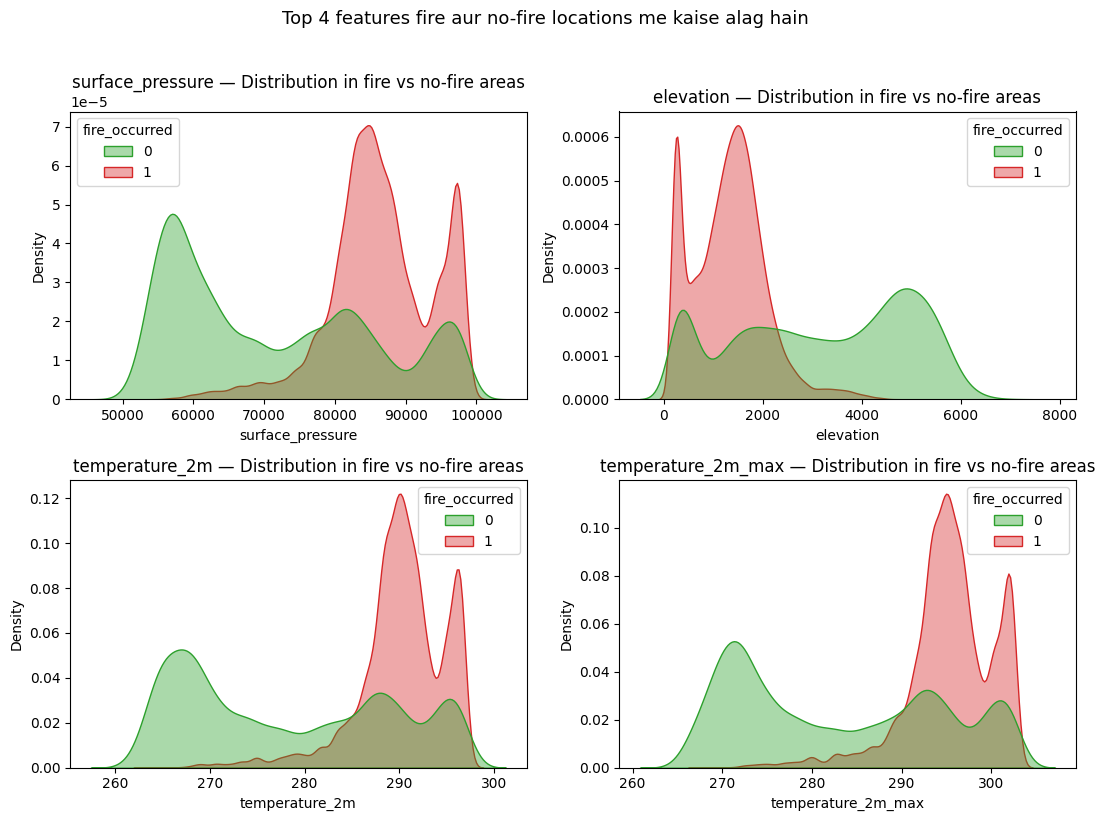

In [53]:
top4 = imp_df["feature"].head(4).tolist()
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.flatten()
for i, feat in enumerate(top4):
    sns.kdeplot(data=df, x=feat, hue="fire_occurred", fill=True,
                common_norm=False, alpha=0.4, ax=axes[i],
                palette={0: "#2ca02c", 1: "#d62728"})
    axes[i].set_title(f"{feat} — Distribution in fire vs no-fire areas")
fig.suptitle("Top 4 features fire aur no-fire locations me kaise alag hain", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

**Correlation heatmap**

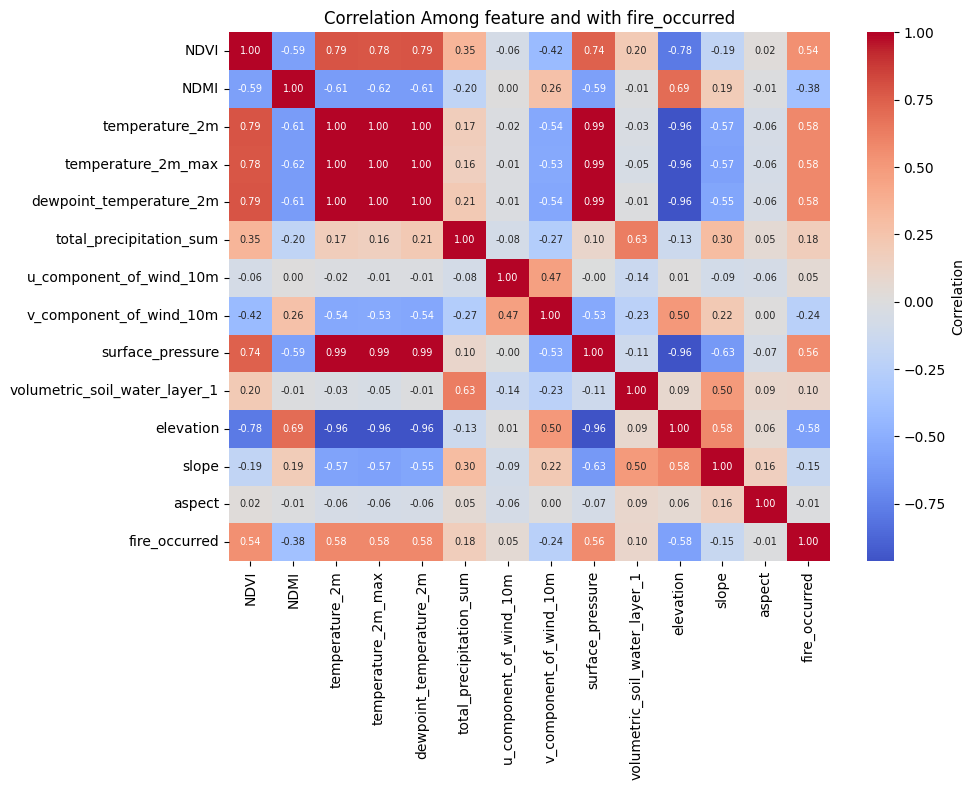

In [54]:
plt.figure(figsize=(10, 8))
corr = df[feature_cols + ["fire_occurred"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 7}, cbar_kws={"label": "Correlation"})
plt.title("Correlation Among feature and with fire_occurred")
plt.tight_layout()
plt.show()

